Try to use Multi-Time Attention to embedding LSST light curves.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from astropy.io import fits
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from ligo.skymap.io.fits import read_sky_map
from ligo.skymap.moc import uniq2nest, uniq2pixarea
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

## Mask Handling in mTAN
对于每个样本，不同波段有不同的观测时间点，选择不同波段观测时间点的并集长度，作为该样本时间长度L，同时不同波段在该时间点上可能有缺失值，因此需要引入mask来指示每个时间点和波段维度上是否有观测值，最终每个样本形状为[L, D]，mask形状为[L, D]。

不同样本之间可能时间长度L不同，因此需要对齐到同一长度，使用padding的方式补齐缺失值为0，同时mask对应位置为0表示该位置为pad，最终一个批次内样本形状为[Batch, L, D]，mask形状为[Batch, L, D]，时间点形状为[Batch, L]。

For each sample, different bands have different observation time points. The union of observation time points across different bands is chosen as the time length L for that sample. Since there may be missing values at certain time points for different bands, a mask is introduced to indicate the presence of observed values at each time point and feature dimension. The final shape for each sample is [L, D], and the mask shape is [L, D].

Different samples may have different time lengths L, so padding is used to align them to the same length. Missing values are padded with 0, and the corresponding positions in the mask are set to 0 to indicate padding. The final shape for a batch of samples is [Batch, L, D], the mask shape is [Batch, L, D], and the time points shape is [Batch, L].

The mTAN module has been updated to accept a mask argument, which indicates the presence of observed values at each time point and feature dimension. This allows the attention mechanism to properly handle missing data by ignoring padded values during the attention computation.

In [3]:
class LearnablePeriodicEmbedding(nn.Module):
    """
    Implements the time embedding phi_h(t) described in Equation (1).
    
    phi_h(t)[i] = w_0h * t + a_0h             if i = 0 (Linear term)
                = sin(w_ih * t + a_ih)        if 0 < i < d_r (Periodic term)
    """
    def __init__(self, num_heads, ref_dim):
        """
        Args:
            num_heads (H): Number of attention heads.
            ref_dim (d_r): Dimension of the reference embedding per head.
        """
        super().__init__()
        self.num_heads = num_heads
        self.ref_dim = ref_dim
        
        # Parameters for the linear term (i=0)
        # Shape: [1, 1, H, 1] for broadcasting over batch and time
        self.w0 = nn.Parameter(torch.empty(1, 1, num_heads, 1)) 
        self.a0 = nn.Parameter(torch.empty(1, 1, num_heads, 1))
        
        # Parameters for the periodic terms (0 < i < d_r)
        # We need (d_r - 1) frequencies per head
        self.wi = nn.Parameter(torch.empty(1, 1, num_heads, ref_dim - 1))
        self.ai = nn.Parameter(torch.empty(1, 1, num_heads, ref_dim - 1))

        self.reset_parameters()


    def reset_parameters(self):
        """
        Custom initialization logic.
        """
        # 1. Linear Terms: Use Xavier Uniform for weights, Zero for bias
        nn.init.xavier_uniform_(self.w0)
        nn.init.zeros_(self.a0)
        
        # 2. Periodic Frequencies (wi): Log-Linear Initialization
        # We want frequencies to span a range (e.g., from 1.0 to 100.0) geometrically.
        # This is similar to the fixed positional encoding in Transformers.
        # Generate exponents linearly spaced
        exponents = torch.linspace(0, self.ref_dim - 2, self.ref_dim - 1)
        
        # Scale factor (e.g., 100.0 means frequencies range from ~1 to ~100)
        # Formula: freq = scale ^ (i / d)
        scale = 100.0
        log_freqs = -math.log(scale) * (exponents / (self.ref_dim - 1))
        freqs = torch.exp(log_freqs) # Shape: [d-1]
        
        # Broadcast to heads [1, 1, H, d-1]
        freq_init = freqs.view(1, 1, 1, -1).repeat(1, 1, self.num_heads, 1)
        
        # Add small random noise so heads are not identical
        freq_noise = torch.randn_like(freq_init) * 0.05
        freq_init = freq_init * torch.exp(freq_noise)
        
        with torch.no_grad():
            self.wi.copy_(freq_init)
        
        # 3. Periodic Phases (ai): Uniform distribution over [0, 2pi]
        nn.init.uniform_(self.ai, 0, 2 * math.pi)

    def forward(self, t):
        """
        Args:
            t: Time points tensor. Shape [Batch, Seq_Len]
            
        Returns:
            phi(t): Embedded time. Shape [Batch, Seq_Len, H, d_r]
        """
        # Expand t to [Batch, Seq_Len, H, 1] to match heads
        t_expanded = t.unsqueeze(-1).unsqueeze(-1).repeat(1, 1, self.num_heads, 1)
        
        # 1. Compute Linear Term (i=0): w_0h * t + a_0h
        # Output: [Batch, Seq_Len, H, 1]
        linear_term = self.w0 * t_expanded + self.a0
        
        # 2. Compute Periodic Terms (i > 0): sin(w_ih * t + a_ih)
        # Output: [Batch, Seq_Len, H, d_r - 1]
        # Note: t_expanded broadcasts against self.wi [1, 1, H, d_r-1]
        periodic_term = torch.sin(self.wi * t_expanded + self.ai)
        
        # 3. Concatenate along the last dimension to form d_r
        # Output: [Batch, Seq_Len, H, d_r]
        return torch.cat([linear_term, periodic_term], dim=-1)


class MultiTimeAttention(nn.Module):
    """
    Updated mTAN module to support unaligned/irregular sampling across dimensions.
    
    Key Change: 
    - Accepts mask of shape [Batch, L, D] (per-variable masking).
    - Computes attention scores independently for each dimension D.
    """
    def __init__(self, input_dim, num_heads, ref_dim, k_dim, output_dim):
        super().__init__()
        self.H = num_heads
        self.D = input_dim
        self.d_k = k_dim
        self.sqrt_dk = math.sqrt(k_dim)
        
        self.W = nn.Linear(ref_dim, k_dim, bias=False)
        self.V = nn.Linear(ref_dim, k_dim, bias=False)
        self.U = nn.Linear(num_heads * input_dim, output_dim)

        self.reset_parameters()
    
    def reset_parameters(self):
        """
        Initialize projection weights.
        """
        # W, V: Xavier Uniform (standard for attention projections)
        nn.init.xavier_uniform_(self.W.weight)
        nn.init.xavier_uniform_(self.V.weight)
        
        # U: Kaiming Uniform (assuming ReLU follows in the next block)
        # If no ReLU follows immediately, Xavier is also acceptable.
        nn.init.kaiming_uniform_(self.U.weight, a=math.sqrt(5))
        if self.U.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.U.weight)
            bound = 1 / math.sqrt(fan_in)
            nn.init.uniform_(self.U.bias, -bound, bound)

    def forward(self, query_emb, key_emb, values, mask=None):
        """
        Args:
            query_emb: [Batch, K, H, d_r]
            key_emb:   [Batch, L, H, d_r]
            values:    [Batch, L, D]
            mask:      [Batch, L, D] <--- Critical Change: Mask is per-dimension
                       (1.0 for observed, 0.0 for padding/missing)

        Returns:
            h: [Batch, K, J]
        """
        batch_size = query_emb.size(0)
        
        # --- 1. Compute Raw Attention Scores (Shared across D) ---
        # Q: [B, K, H, d_k]
        # K: [B, L, H, d_k]
        Q_proj = self.W(query_emb) 
        K_proj = self.V(key_emb)
        
        # Permute for matmul
        Q_perm = Q_proj.permute(0, 2, 1, 3) # [B, H, K, d_k]
        K_perm = K_proj.permute(0, 2, 1, 3) # [B, H, L, d_k]
        
        # Raw Scores: [B, H, K, L]
        # This represents similarity between Reference Time K and Observed Time L
        scores = torch.matmul(Q_perm, K_perm.transpose(-1, -2)) / self.sqrt_dk
        
        # --- 2. Handle Dimension-Specific Masking ---
        # We need independent attention distributions for each feature dimension D.
        # Eq (4) says Softmax is over observed points t_id *for that dimension*.
        
        # Expand Scores to D: [B, H, K, L, 1] -> [B, H, K, L, D]
        scores_expanded = scores.unsqueeze(-1).expand(-1, -1, -1, -1, self.D)
        
        if mask is not None:
            # Mask input: [B, L, D]
            # Expand Mask to match scores: [B, 1, 1, L, D]
            mask_expanded = mask.unsqueeze(1).unsqueeze(1)
            
            # Apply Mask: Set scores of missing bands/times to -inf
            # This ensures exp(-inf) = 0 in Softmax
            scores_expanded = scores_expanded.masked_fill(mask_expanded == 0, -1e9)
        
        # --- 3. Compute Softmax per Dimension ---
        # Softmax over L dimension (dim=3)
        # attn_weights: [B, H, K, L, D]
        # Now each dimension d has its own attention distribution based on its valid times.
        attn_weights = F.softmax(scores_expanded, dim=3)
        
        # --- 4. Weighted Sum (Interpolation) ---
        # values: [B, L, D] -> [B, 1, 1, L, D]
        v_expanded = values.unsqueeze(1).unsqueeze(1)
        
        # Element-wise multiplication broadcasted over H and K
        # Then sum over L (time axis)
        # x_hat: [B, H, K, D]
        x_hat = torch.sum(attn_weights * v_expanded, dim=3)
        
        # --- 5. Final Projection ---
        # Flatten H and D: [B, K, H * D]
        x_hat_flat = x_hat.permute(0, 2, 1, 3).reshape(batch_size, -1, self.H * self.D)
        
        output = self.U(x_hat_flat) # [Batch, K, J]
        
        return output

class OpticalEncoderWithCLS(nn.Module):
    """
    Wrapper module for the Optical Encoder in the GW-Optical architecture.
    It combines:
      1. Periodic Time Embedding
      2. CLS Token Injection
      3. mTAN Attention Module
    """
    def __init__(self, input_dim, num_heads=4, ref_dim=64, k_dim=64, output_dim=128):
        super().__init__()
        self.num_heads = num_heads
        self.ref_dim = ref_dim
        
        # [cite_start]1. Time Embedding Layer (phi) [cite: 5, 6]
        self.time_embedding = LearnablePeriodicEmbedding(num_heads, ref_dim)
        
        # 2. Learnable CLS Token Parameter
        # This replaces phi(t) for the first token. 
        # Dimensions must match the embedded time: [1, 1, H, d_r]
        self.cls_token = nn.Parameter(torch.empty(1, 1, num_heads, ref_dim))
        nn.init.normal_(self.cls_token, mean=0.0, std=0.02) # BERT initialization
        self.cls_token.requires_grad = True
        
        # [cite_start]3. mTAN Core Module [cite: 3, 4]
        self.mtan = MultiTimeAttention(input_dim, num_heads, ref_dim, k_dim, output_dim)

    def forward(self, t_obs, values_obs, t_ref, mask=None):
        """
        Args:
            t_obs: [Batch, L] (Union of all time points)
            values_obs: [Batch, L, D] (Values, padded with 0 where missing)
            t_ref: [Batch, N]
            mask: [Batch, L, D] (1 if band d is observed at time l, else 0)
            
        Returns:
            z_l: The global CLS vector [Batch, J] (for Alignment)
            H_l: The temporal matrix [Batch, N, J] (for Fusion)
        """
        batch_size = t_obs.size(0)
        
        # 1. Embed Observed Times (Keys) -> phi(t_id)
        # Shape: [Batch, L, H, d_r]
        key_emb = self.time_embedding(t_obs)
        
        # 2. Embed Reference Times (Queries Part A) -> phi(t)
        # Shape: [Batch, N, H, d_r]
        ref_time_emb = self.time_embedding(t_ref)
        
        # 3. Prepare CLS Token (Queries Part B)
        # Expand learnable parameter to batch size
        # Shape: [Batch, 1, H, d_r]
        cls_emb = self.cls_token.expand(batch_size, -1, -1, -1)
        
        # 4. Concatenate CLS and Reference Embeddings
        # Total Query Shape: [Batch, N + 1, H, d_r]
        query_emb = torch.cat([cls_emb, ref_time_emb], dim=1)
        
        # 5. Pass through mTAN
        # Output Shape: [Batch, N + 1, J]
        full_output = self.mtan(query_emb, key_emb, values_obs, mask)
        
        # 6. Split Output
        # Index 0 is CLS (z_l), Indices 1..N are time-series (H_l)
        z_l = full_output[:, 0, :]   # [Batch, J]
        H_l = full_output[:, 1:, :]  # [Batch, N, J]
        
        return z_l, H_l

In [4]:
# load data for test
injections = pd.read_csv("/fred/oz016/bgao_kn/ML+GW+KN/dataset/O5_sim_bns/injections_final.csv")
sim_id = 16
SIM_PATH = "/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/LSST_KN_BNS"
phot_file = os.path.join(SIM_PATH, f"LSST_KN_BNS_{sim_id}", f"LSST_KN_BNS_{sim_id}_PHOT.FITS")
head_file = os.path.join(SIM_PATH, f"LSST_KN_BNS_{sim_id}", f"LSST_KN_BNS_{sim_id}_HEAD.FITS")
# 打开PHOT.fits文件
phot_hdul = fits.open(phot_file)
phot_data = phot_hdul[1].data

# 打开HEAD.fits文件，获取每个源的光变曲线索引分界
head_hdul = fits.open(head_file)
head_data = head_hdul[1].data
start_indices = head_data['PTROBS_MIN']
end_indices = head_data['PTROBS_MAX']

mjd_explode = injections['mjd_time'][np.where(injections['simulation_id']==sim_id)[0]].values
head_data

FITS_rec([('169', 2, 38.144531, -27.279613, 0.2, -9, -9, 0,  98,   1,  98, 0.01450893, 0.00232143, 0.07379024, 0., 0.073116, 0., 2, 0., 0., 0., 0., 0, 0, 0, 0, -9., -9., -9., -9., -999., -999., -9., -9., -99., -9999., -9999., -9999., -9999., -9999., -9999., -9999., -9999., -9999., 0, -9999., 0, 999., 999., 999., 999., 999., 999., 999., 999., 999., 999., 999., 999., 0, 0, -9., -9., -9., -9., -999., -999., -9., -9., -9999., -9999., -9999., -9999., -9999., -9999., -9999., -9999., -9999., 0, -9999., 0, 999., 999., 999., 999., 999., 999., 999., 999., 999., 999., 999., 999., -999., -999., -999., -999., -999., -999., 63199.246, 63198.242, 63198.22, 63200.246, -9, 'SIMSED.BULLA-BNS-M3-3COMP', 7, 0, 0, 'BULLA-BNS-M3', 758,  168, 1, 0, 3, 0.07379024, 0.073116, 0.07379024, 0., 1,  0., -9, 0., 0., 37.594948, 0., 0., 38.14453125, -27.27961349, 0.01278942, 63197.695, 63197.793, 0., 1., -9., -9., 9.1626508e-16, 0.5465776 , 0.002886, 0.023251, 38.933426, 843.6194 , 99., 99., 99., 99., 99., 99., 1., 1.

Plotting source 1,Merger MJD: 63197.6935 PEAKMJD: 63199.24609375, Index range: 1-98
Plotting source 2,Merger MJD: 63197.6935 PEAKMJD: 63199.25390625, Index range: 100-186
Plotting source 3,Merger MJD: 63197.6935 PEAKMJD: 63198.2421875, Index range: 188-260
Plotting source 4,Merger MJD: 63197.6935 PEAKMJD: 63199.25390625, Index range: 262-362
Plotting source 5,Merger MJD: 63197.6935 PEAKMJD: 63199.25390625, Index range: 364-454


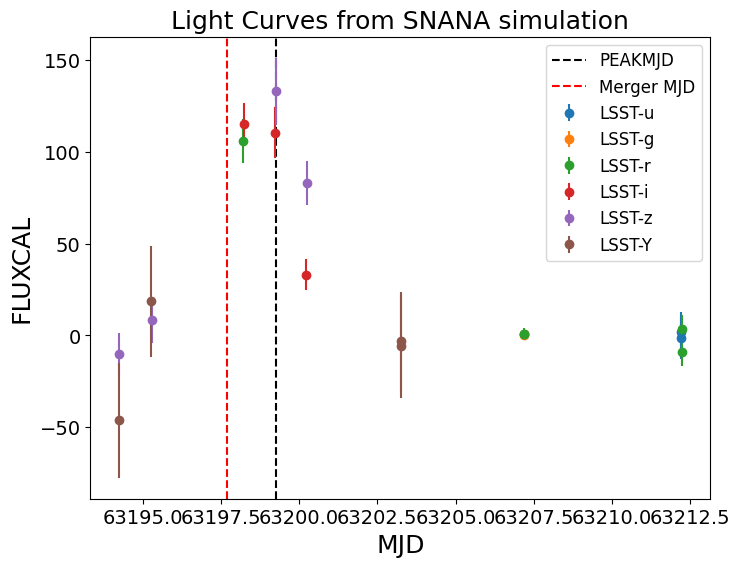

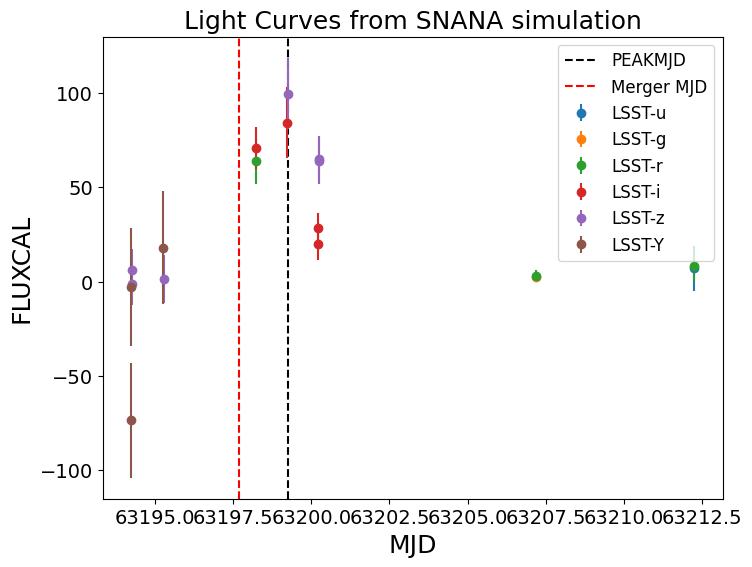

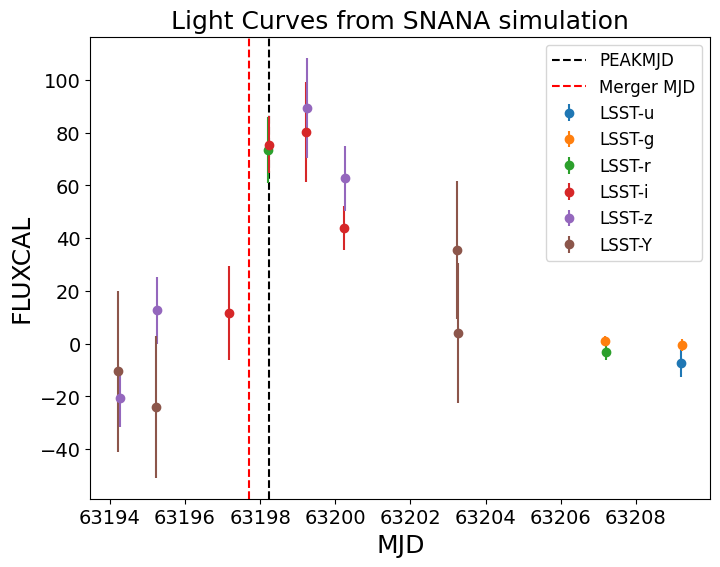

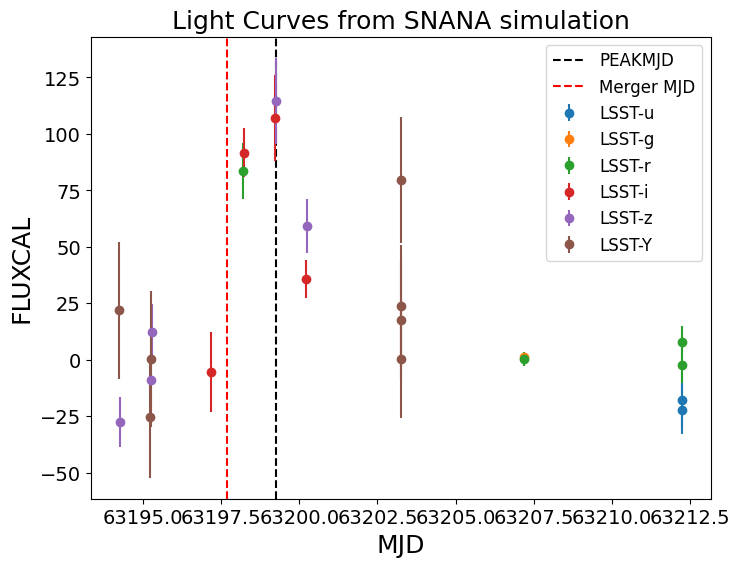

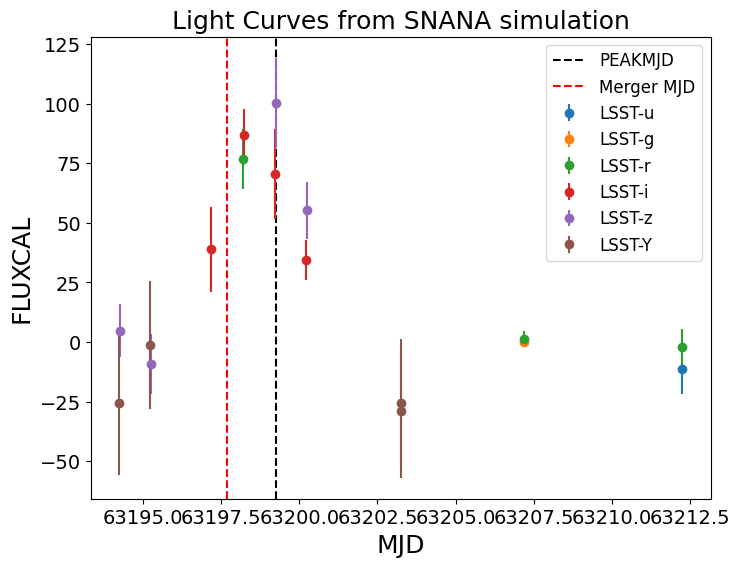

In [5]:
bands = ['LSST-u','LSST-g','LSST-r','LSST-i','LSST-z','LSST-Y']
for i, (start, end) in enumerate(zip(start_indices, end_indices)):
    plt.figure(figsize=(8,6))
    peakmjd = head_data['PEAKMJD'][i]
    print(f'Plotting source {i+1},Merger MJD: {mjd_explode[0]} PEAKMJD: {peakmjd}, Index range: {start}-{end}')
    plt.axvline(x=peakmjd, color='k', linestyle='--', label='PEAKMJD')
    plt.axvline(x=mjd_explode[0], color='r', linestyle='--', label="Merger MJD")
    source_data = phot_data[start-1:end]  # FITS索引通常从1开始
    source_data = source_data[np.logical_and(source_data['MJD']>=mjd_explode[0]-5, source_data['MJD']<=mjd_explode[0]+15)]
    mjd = source_data['MJD']
    flux = source_data['FLUXCAL']
    fluxerr = source_data['FLUXCALERR']
    # mag, magerr = convert_fluxcal_to_mag(flux=flux.copy(), err=fluxerr)
    for band in bands:
        band_mask = source_data['BAND'] == band
        # plt.errorbar(mjd[band_mask], mag[band_mask], yerr=magerr[band_mask], fmt='o', label=band)
        plt.errorbar(mjd[band_mask], flux[band_mask], yerr=fluxerr[band_mask], fmt='o', label=band)
        # plt.errorbar(mjd, flux, yerr=err, fmt='o', label=f'Source {i+1}')
        plt.xlabel('MJD', fontsize=18)
        plt.xticks(fontsize=14)
        plt.ylabel('FLUXCAL', fontsize=18)
        plt.yticks(fontsize=14)
        plt.title('Light Curves from SNANA simulation', fontsize=18)
        plt.legend(fontsize=12)

In [6]:
index = 0
bands = ['LSST-u','LSST-g','LSST-r','LSST-i','LSST-z','LSST-Y']
source_data = phot_data[start_indices[index]-1:end_indices[index]]

t_obs, indices = torch.sort(torch.tensor(np.array(source_data['MJD'] - mjd_explode[0]).astype(np.float32), dtype=torch.float32).unsqueeze(0))  # [1, L]
values_obs = torch.tensor(np.array(source_data['FLUXCAL']).astype(np.float32), dtype=torch.float32)[indices].unsqueeze(-1)  # [1, L, 1]
values_obs = values_obs.repeat(1, 1, len(bands))  # [1, L, D]
print(t_obs.shape, values_obs.shape)
print(indices)
print(t_obs[0,:2])
print(values_obs[0,:2,:])

# mask lightcurves for each band
mask = np.zeros((1, t_obs.size(1), len(bands)), dtype=np.float32)  # [1, L, D]
for i, band in enumerate(bands):
    band_mask = source_data['BAND'] == band
    mask[0, band_mask, i] = 1.0  # Mark observed points
mask_tensor = torch.tensor(mask, dtype=torch.float32)  # [1, L, D]

v_mask = values_obs * mask_tensor
print(v_mask[0,:2,:])
print(mask_tensor.shape)
print(mask_tensor[0,:2,:])

torch.Size([1, 98]) torch.Size([1, 98, 6])
tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
         36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
         54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,
         72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89,
         90, 91, 92, 93, 94, 95, 96, 97]])
tensor([-29.4184, -29.3962])
tensor([[ 5.3903,  5.3903,  5.3903,  5.3903,  5.3903,  5.3903],
        [50.7202, 50.7202, 50.7202, 50.7202, 50.7202, 50.7202]])
tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  5.3903],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000, 50.7202]])
torch.Size([1, 98, 6])
tensor([[0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 1.]])


In [61]:
# ==============================================================================
#                               Usage Example
# ==============================================================================
print("-" * 50)
print("Testing mTAN with CLS Token Implementation")
print("-" * 50)

torch.manual_seed(42)
bands = ['LSST-u','LSST-g','LSST-r','LSST-i','LSST-z','LSST-Y']
# --- Configuration ---
BATCH_SIZE = 4
UNION_LEN = len(source_data)     # Length of the union of all time points (L)
NUM_REF = 64       # Number of reference points (N)
INPUT_DIM = len(bands)      # Number of Bands (D), e.g., ugrizy
OUTPUT_DIM = 128   # Final dimension (J)

# --- Instantiate Model ---
model = OpticalEncoderWithCLS(input_dim=INPUT_DIM, output_dim=OUTPUT_DIM)

# --- Generate Dummy Data (Simulating LSST Light Curves) ---

# 1. Union of Time Points (t_obs)
# Different bands observe at different times, but we flatten them to a sorted union vector.
t_obs, indices = torch.sort(torch.tensor(np.array(source_data['MJD'] - mjd_explode[0]).astype(np.float32), dtype=torch.float16).unsqueeze(0))
t_obs = t_obs.repeat(BATCH_SIZE, 1)  # [B, L]

# 2. Values (v_obs)
# Random flux values. We fill everything first, then mask out missing ones.
v_obs = torch.tensor(np.array(source_data['FLUXCAL']).astype(np.float32), dtype=torch.float16)[indices].unsqueeze(-1)
v_obs = v_obs.repeat(BATCH_SIZE, 1, len(bands))

# 3. Mask (Per-Dimension!) -> [Batch, L, D]
# mask[b, l, d] = 1 means band d is observed at time l.
# mask lightcurves for each band
mask = np.zeros((BATCH_SIZE, t_obs.size(1), len(bands)), dtype=np.float32)  # [B, L, D]
for i, band in enumerate(bands):
    band_mask = source_data['BAND'] == band
    mask[0, band_mask, i] = 1.0  # Mark observed points
mask = torch.tensor(mask, dtype=torch.float32)  # [B, L, D]

# Apply mask to values (Optional! set unobserved values to 0 for clarity; mTAN ignores them via mask)
# v_obs = v_obs * mask

# 4. Reference Time Points (t_ref)
t_ref = torch.linspace(-30, 90, NUM_REF).unsqueeze(0).repeat(BATCH_SIZE, 1)

print(f"Input Data Shapes:")
print(f"  - t_obs:  {t_obs.shape} (Union Time Points)")
print(f"  - v_obs:  {v_obs.shape} (Flux Values)")
print(f"  - mask:   {mask.shape}  (Per-Band Validity Mask [B, L, D])")
print(f"  - t_ref:  {t_ref.shape} (Reference Query Times)")

# --- Forward Pass ---
try:
    z_l, H_l = model(t_obs, v_obs, t_ref, mask)
    
    print("\n" + "-"*20 + " OUTPUTS " + "-"*20)
    print(f"Success! Model handled unaligned masking.")
    print(f"  - z_l (CLS Vector):      {z_l.shape}  -> Expected: [{BATCH_SIZE}, {OUTPUT_DIM}]")
    print(f"  - H_l (Temporal Matrix): {H_l.shape} -> Expected: [{BATCH_SIZE}, {NUM_REF}, {OUTPUT_DIM}]")
    
    # # Verify gradient flow (optional)
    # loss = z_l.sum() + H_l.sum()
    # loss.backward()
    # print("CLS vector:", z_l)
    # print("Temporal matrix:", H_l)
    # print("  - Backward pass successful (Gradients computed).")
    
except Exception as e:
    print(f"\nError during forward pass: {e}")

--------------------------------------------------
Testing mTAN with CLS Token Implementation
--------------------------------------------------
Input Data Shapes:
  - t_obs:  torch.Size([4, 98]) (Union Time Points)
  - v_obs:  torch.Size([4, 98, 6]) (Flux Values)
  - mask:   torch.Size([4, 98, 6])  (Per-Band Validity Mask [B, L, D])
  - t_ref:  torch.Size([4, 64]) (Reference Query Times)

-------------------- OUTPUTS --------------------
Success! Model handled unaligned masking.
  - z_l (CLS Vector):      torch.Size([4, 128])  -> Expected: [4, 128]
  - H_l (Temporal Matrix): torch.Size([4, 64, 128]) -> Expected: [4, 64, 128]


## MLP Head for Gravitational Wave data

In [62]:
# ==============================================================================
# 1. 1D ResNet Basic Module
# ==============================================================================
class BasicBlock1D(nn.Module):
    """
    1D version of the ResNet BasicBlock.
    """
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock1D, self).__init__()
        
        # First convolution: handling stride for downsampling
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        
        # Second convolution
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)

        # Shortcut connection:
        # If input shape (channels or length) differs from output, project input to match.
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(self.expansion * out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet1D(nn.Module):
    """
    1D ResNet Encoder designed for long sequences (e.g., MOC Skymaps).
    Architecture is based on ResNet-18 but adapted for 1D data.
    """
    def __init__(self, in_channels, hidden_dim=256, output_dim=128):
        """
        Args:
            in_channels: Number of input channels (flexible, not fixed to 5).
            hidden_dim: Dimension of the hidden layer in the projection head.
            output_dim: Dimension of the final output vector.
        """
        super(ResNet1D, self).__init__()
        self.current_planes = 64
        
        # Initial Convolution: Rapidly downsample high-res input
        # Input: [B, in_channels, L=19200] -> Output: [B, 64, L/4=4800] (Stride=4)
        self.conv1 = nn.Conv1d(in_channels, 64, kernel_size=7, stride=4, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)
        # Pooling: [B, 64, L/4=4800] -> [B, 64, L/8=2400]
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)

        # ResNet Layers (Stacking Blocks)
        # Layer 1: Keep dimension 64, Length same
        self.layer1 = self._make_layer(64, 64, blocks=2, stride=1)
        # Layer 2: Dim 64 -> 128, Length halved
        self.layer2 = self._make_layer(64, 128, blocks=2, stride=2)
        # Layer 3: Dim 128 -> 256, Length halved
        self.layer3 = self._make_layer(128, 256, blocks=2, stride=2)
        # Layer 4: Dim 256 -> 512, Length halved
        self.layer4 = self._make_layer(256, 512, blocks=2, stride=2)

        # Global Average Pooling + Fully Connected Head
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(512 * BasicBlock1D.expansion, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def _make_layer(self, in_planes, planes, blocks, stride):
        layers = []
        # The first block in a layer handles the stride (downsampling)
        layers.append(BasicBlock1D(in_planes, planes, stride))
        
        # Subsequent blocks maintain the dimension
        # (Note: For BasicBlock, expansion is 1, so in_planes matches planes)
        for _ in range(1, blocks):
            layers.append(BasicBlock1D(planes, planes))
            
        return nn.Sequential(*layers)

    def forward(self, x):
        # x shape: [Batch, in_channels, Length]
        x = self.conv1(x)   # [Batch, 64, L/4=4800]
        x = self.bn1(x)  # [Batch, 64, L/4=4800]
        x = self.relu(x)    
        x = self.maxpool(x)  # [Batch, 64, L/8=2400]

        x = self.layer1(x)  # [Batch, 64, L/8=2400]
        x = self.layer2(x)  # [Batch, 128, L/16=1200]
        x = self.layer3(x)  # [Batch, 256, L/32=600]
        x = self.layer4(x)  # [Batch, 512, L/64=300]

        x = self.avgpool(x) # [Batch, 512, 1]
        x = x.flatten(1)    # [Batch, 512]
        x = self.fc(x)      # [Batch, Output_Dim]
        
        return x

# ==============================================================================
# 2. Dual-Stream Fusion Encoder
# ==============================================================================
class GWMOCResNetEncoder(nn.Module):
    """
    Dual-Stream Encoder:
    1. Scalar Stream: MLP for mass, spin, etc.
    2. Image/Sequence Stream: 1D ResNet for MOC Skymap sequences.
    """
    def __init__(self, 
                 scalar_input_dim, 
                 skymap_channels,          # <--- Flexible channel input
                 scalar_hidden_dim=256, 
                 resnet_output_dim=128,
                 final_output_dim=128):
        super().__init__()
        
        # --- 1. Scalar Encoder (MLP) ---
        self.scalar_enc = nn.Sequential(
            nn.Linear(scalar_input_dim, scalar_hidden_dim),
            nn.BatchNorm1d(scalar_hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(scalar_hidden_dim, scalar_hidden_dim),
            nn.BatchNorm1d(scalar_hidden_dim),
            nn.ReLU()
        )
        
        # --- 2. Skymap Encoder (1D ResNet) ---
        # Initialize ResNet with the specific number of channels provided
        self.skymap_enc = ResNet1D(
            in_channels=skymap_channels,
            output_dim=resnet_output_dim
        )
        
        # --- 3. Fusion Layer ---
        # Concatenate both features and project to final 'g' vector
        fusion_input_dim = scalar_hidden_dim + resnet_output_dim
        self.fusion_head = nn.Sequential(
            nn.Linear(fusion_input_dim, final_output_dim * 2),
            nn.BatchNorm1d(final_output_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(final_output_dim * 2, final_output_dim) 
            # Final output 'g' vector
        )

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        """
        Custom weight initialization for Conv1d, Linear, and BatchNorm1d layers.
        """
        for m in self.modules():
            # 1. Process Convolutional Layers (Conv1d)
            if isinstance(m, nn.Conv1d):
                # mode='fan_out' , making constant variance in the backward pass
                # nonlinearity='relu' for ReLU activations
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            
            # 2. Process Fully Connected Layers (Linear)
            elif isinstance(m, nn.Linear):
                # Linear layers also use Kaiming initialization (Xavier is also possible, but Kaiming is better after ReLU)
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            
            # 3. Process Normalization Layers (BatchNorm1d) - Standard initialization
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        
        # 4. ResNet Zero-Gamma Initialization
        # For each BasicBlock1D in ResNet, set the last BatchNorm weight to zero
        for m in self.modules():
            if isinstance(m, BasicBlock1D):
                # Set bn2 weight to zero
                nn.init.constant_(m.bn2.weight, 0)
    

    def forward(self, gw_scalars, skymap_sequence):
        """
        Args:
            gw_scalars: [Batch, D_scalar]
            skymap_sequence: [Batch, skymap_channels, Length] 
                             (e.g., [B, 7, 19200])
        Returns:
            g: [Batch, Final_Dim]
        """
        # Encode Scalars
        h_scalar = self.scalar_enc(gw_scalars)  # [B, scalar_hidden]
        
        # Encode Skymap Sequence
        h_skymap = self.skymap_enc(skymap_sequence) # [B, resnet_output]
        
        # Concatenate
        combined = torch.cat([h_scalar, h_skymap], dim=1)   # [B, fusion_input_dim]
        
        # Fuse
        g = self.fusion_head(combined)  # [B, final_output_dim]
        
        return g

In [63]:
def sample_moc_skymap(map_file):
    """
    Convert UNIQ to sky coordinates and calculte pixel areas.
    Note: Do not include DISTNORM in the output. For inf values in DISTMU, relace with distmean and diststd from metadata.
    """
    import healpy as hp
    
    # read moc skymap and metadata
    moc_map = read_sky_map(map_file, moc=True, distances=True)
    _, meta = read_sky_map(map_file, nest=True)

    # extract distance meta info
    dist_mean = meta.get('distmean', None)
    dist_std = meta.get('diststd', None)

    uniq = moc_map['UNIQ']
    probdensity = moc_map['PROBDENSITY']
    distmu = moc_map['DISTMU']
    distsigma = moc_map['DISTSIGMA']
    distnorm = moc_map['DISTNORM']

    # 1) UNIQ -> order, ipix, nside
    order, ipix = uniq2nest(uniq)

    # 2) caculate pixel area
    dA = uniq2pixarea(uniq)
    # 3) calculate pixel probability
    dP = probdensity * dA
    # 4) calculate theta, phi
    ras  = np.zeros_like(ipix, dtype=np.float32)
    decs = np.zeros_like(ipix, dtype=np.float32)
    for k in np.unique(order):
        m = (order == k)
        this_ipix  = ipix[m]
        this_nside = 2 ** k
        theta, phi = hp.pix2ang(this_nside, this_ipix, nest=True)
        ras[m]  = np.degrees(phi)
        decs[m] = 90.0 - np.degrees(theta)
    
    # 5) return torch tensors
    gw_mocmap = torch.tensor(np.vstack([ras, decs,dA, dP, distmu, distsigma]), dtype=torch.float32)   # [6, N_pixels], no distnorm

    # 6) process unnormal distance values
    inf_dist_mu = torch.where(torch.isinf(gw_mocmap[4]))[0]
    gw_mocmap[4, inf_dist_mu] = dist_mean  # set inf to mean value
    gw_mocmap[5, inf_dist_mu] = dist_std   # set inf to std value

    return gw_mocmap  # [6, N_pixels]

In [64]:
skympap_file = "/fred/oz016/bgao_kn/data/bns_skymap/16.fits"
gw_mocmap = sample_moc_skymap(skympap_file)
print(gw_mocmap[:,0])
print(gw_mocmap.shape)  # Expected: [6, Num_Pixels]

tensor([4.5000e+01, 2.3880e+00, 4.0906e-03, 9.6972e-07, 5.6729e+02, 3.5504e+02])
torch.Size([6, 19200])


In [65]:
# Check for inf and NaN values in gw_mocmap
print("Checking gw_mocmap for inf values:")
print("-" * 50)

# Check for inf
has_inf = torch.isinf(gw_mocmap).any()
num_inf = torch.isinf(gw_mocmap).sum().item()
print(f"Contains Inf: {has_inf}")
print(f"Number of Inf values: {num_inf}")

# Find positions of Inf values (if any)
if has_inf:
    inf_positions = torch.where(torch.isinf(gw_mocmap))
    print(f"\nInf positions (channel, index):")
    for i in range(len(inf_positions[0])):
        channel = inf_positions[0][i].item()
        idx = inf_positions[1][i].item()
        print(f"  Channel {channel}, Index {idx}, Value: {gw_mocmap[channel, idx]}")

# Statistical summary per channel
print("\nStatistical summary per channel:")
channel_names = ['RA', 'DEC', 'Area', 'Prob', 'DistMu', 'DistSigma']
for i, name in enumerate(channel_names):
    channel_data = gw_mocmap[i]
    print(f"{name:12s}: min={channel_data.min():.6f}, max={channel_data.max():.6f}, "
          f"mean={channel_data.mean():.6f}, std={channel_data.std():.6f}")

Checking gw_mocmap for inf values:
--------------------------------------------------
Contains Inf: False
Number of Inf values: 0

Statistical summary per channel:
RA          : min=0.000000, max=357.187500, mean=223.627396, std=90.757469
DEC         : min=-87.075821, max=87.075821, mean=15.999136, std=34.076427
Area        : min=0.000004, max=0.004091, mean=0.000654, std=0.001302
Prob        : min=0.000000, max=0.000125, mean=0.000052, std=0.000029
DistMu      : min=-78464.960938, max=1191.656250, mean=301.515717, std=1608.696533
DistSigma   : min=130.309067, max=4807.598145, mean=268.740692, std=159.238480


In [66]:
injections = pd.read_csv("/fred/oz016/bgao_kn/ML+GW+KN/dataset/O5_sim_bns/injections_final.csv", index_col=0)
gw_params_name = ['mjd_time', 'gps_time', 'mass1', 'mass2', 'spin1z', 'spin2z', 'inclination', 'distmean', 'diststd']
gw_params = injections[gw_params_name].loc[16].values
gw_params = torch.tensor(gw_params, dtype=torch.float32).unsqueeze(0)  # [1, 9]
print(gw_params.shape)  # [1, 9]

torch.Size([1, 9])


In [67]:
print("-" * 50)
print("Testing GW Encoder with Flexible Channel ResNet-1D")
print("-" * 50)

torch.manual_seed(42)
# Configuration
BATCH_SIZE = 4
SCALAR_DIM = 9       # Mass, Spin, etc.

# TEST CASE: Using 6 channels instead of 5 to prove flexibility
# e.g., [ra, dec, area, prob, dist_mu, dist_sigma]
SKYMAP_CHANNELS = 6   
MOC_LENGTH = 19200    # Fixed length sequence
OUTPUT_DIM = 128

# Initialize Model
model = GWMOCResNetEncoder(
    scalar_input_dim=SCALAR_DIM,
    skymap_channels=SKYMAP_CHANNELS, # Passing the dynamic channel count
    final_output_dim=OUTPUT_DIM
)

# Set to evaluation mode to avoid BatchNorm errors with batch_size=1
# model.eval()

# Dummy Data Generation
gw_scalars = gw_params.repeat(BATCH_SIZE, 1)  # [B, 9]

# Random input matching the defined SKYMAP_CHANNELS
gw_moc = gw_mocmap.unsqueeze(0).repeat(BATCH_SIZE, 1, 1)  # [B, 6, 19200]
# gw_moc = torch.ones_like(gw_moc)  # Using ones for simplicity

print(f"Scalar Input Shape: {gw_scalars.shape}")
print(f"MOC Input Shape:    {gw_moc.shape} (Channels={SKYMAP_CHANNELS})")
# print("GW parameters Input:", gw_scalars)
# print("MOC skymap Input:", gw_moc)

# Forward Pass
g = model(gw_scalars, gw_moc)
print(f"Output g Shape:     {g.shape}")
print(f"Expected Shape:     ({BATCH_SIZE}, {OUTPUT_DIM})")


# Verification
if g.shape == (BATCH_SIZE, OUTPUT_DIM):
    # print("GW embedding vector g:", g)
    print(">> Success: Architecture handles flexible channels correctly.")
else:
    print(">> Failure: Incorrect output dimensions.")

--------------------------------------------------
Testing GW Encoder with Flexible Channel ResNet-1D
--------------------------------------------------
Scalar Input Shape: torch.Size([4, 9])
MOC Input Shape:    torch.Size([4, 6, 19200]) (Channels=6)
Output g Shape:     torch.Size([4, 128])
Expected Shape:     (4, 128)
>> Success: Architecture handles flexible channels correctly.


In [68]:
class ProjectionHead(nn.Module):
    """
    MLP Projection Head used in Contrastive Learning (SimCLR/MoCo/ALBEF style).
    Projects features from Encoder Dim -> Latent Dim.
    """
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, output_dim)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.net(x)

class GWOpticalAlignment(nn.Module):
    """
    Alignment Branch for Multi-Modal Contrastive Learning.
    Calculates the ITC (Image-Text Contrastive) Loss.
    """
    def __init__(self, gw_dim=128, opt_dim=128, project_dim=256, init_temp=0.07):
        """
        Args:
            gw_dim: Input dimension of GW vector 'g'.
            opt_dim: Input dimension of Optical vector 'z_l'.
            project_dim: Dimension of the shared latent space.
            init_temp: Initial value for the learnable temperature parameter.
        """
        super().__init__()
        
        # 1. Independent Projection Heads
        # Even if input dims are same, use separate heads because modalities differ.
        self.gw_proj = ProjectionHead(gw_dim, gw_dim, project_dim)
        self.opt_proj = ProjectionHead(opt_dim, opt_dim, project_dim)
        
        # 2. Learnable Temperature Parameter
        # We store log_temp to ensure temperature is always positive (via exp)
        self.log_temp = nn.Parameter(torch.ones([]) * torch.log(torch.tensor(init_temp)))
        
        # 3. Standard Cross Entropy Loss
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, g, z_l):
        """
        Args:
            g: GW features [Batch, gw_dim]
            z_l: Optical CLS features [Batch, opt_dim]
            
        Returns:
            loss: The scalar contrastive loss value.
            sim_matrix: Similarity matrix (useful for monitoring/logging).
        """
        # 1. Project features
        # [Batch, project_dim]
        proj_g = self.gw_proj(g)
        proj_o = self.opt_proj(z_l)
        
        # 2. L2 Normalize (Crucial for Cosine Similarity)
        # vectors lie on a hypersphere unit surface
        proj_g = F.normalize(proj_g, dim=1)
        proj_o = F.normalize(proj_o, dim=1)
        
        # 3. Retrieve Temperature
        # Clamp to prevent numerical instability (too small) or collapse (too large)
        logit_scale = torch.clamp(self.log_temp.exp(), min=0.01, max=100.0)
        
        # 4. Compute Similarity Matrix (Logits)
        # [Batch, Batch] = [Batch, Dim] @ [Dim, Batch]
        # Element (i, j) is the similarity between GW_i and Optical_j
        logits_g2o = torch.matmul(proj_g, proj_o.T) * logit_scale
        logits_o2g = logits_g2o.T
        
        # 5. Generate Labels
        # The positive pair for GW_i is Optical_i.
        # So the target labels are the diagonal indices: [0, 1, 2, ..., Batch-1]
        batch_size = g.size(0)
        labels = torch.arange(batch_size, device=g.device)
        
        # 6. Compute Symmetric Loss
        # Loss 1: Given GW, classify correct Optical
        loss_g = self.criterion(logits_g2o, labels)
        # Loss 2: Given Optical, classify correct GW
        loss_o = self.criterion(logits_o2g, labels)
        
        loss = (loss_g + loss_o) / 2
        
        return loss

In [69]:
print("-" * 50)
print("Testing Alignment Branch (Contrastive Learning)")
print("-" * 50)

torch.manual_seed(42)
BATCH_SIZE = 4
ENC_DIM = 128
PROJ_DIM = 256

# Initialize Module
alignment_model = GWOpticalAlignment(gw_dim=ENC_DIM, opt_dim=ENC_DIM, project_dim=PROJ_DIM)

# Dummy Inputs (simulating output from encoders)
# Note: These are NOT normalized yet, the module handles it.
# g_vec = torch.randn(BATCH_SIZE, ENC_DIM)
# z_l_vec = torch.randn(BATCH_SIZE, ENC_DIM)

# 模拟“完全对齐”的情况 (为了测试 Loss 是否下降)
# 让 z_l 只是 g 的一个微小扰动，这样它们应该很相似
# z_l_perfect = g_vec + 0.1 * torch.randn_like(g_vec)

# Forward Pass
loss = alignment_model(g, z_l)

print(f"Inputs: g {g.shape}, z_l {z_l.shape}")
print(f"Projection Dim: {PROJ_DIM}")
print(f"Computed Loss: {loss.item():.4f}")
print(f"Initial Temp: {alignment_model.log_temp.exp().item():.4f}")

# Check gradients
loss.backward()
print("Backward pass successful (Gradients computed).")

# 理论验证：
# 如果 Batch Size = 8，随机猜测的 Accuracy 是 1/8。
# 初始 Loss 应该接近 -log(1/8) = log(8) ≈ 2.079
# 如果输入特征高度相关（如上面的 z_l_perfect），Loss 应该显著低于 2.0
expected_random_loss = torch.log(torch.tensor(float(BATCH_SIZE)))
print(f"Expected Random Loss: ~{expected_random_loss.item():.4f}")

if loss.item() < expected_random_loss.item():
    print(">> Validation: Loss is lower than random guess (as expected for correlated inputs).")
else:
    print(">> Warning: Loss is high, check similarity calculation.")

--------------------------------------------------
Testing Alignment Branch (Contrastive Learning)
--------------------------------------------------
Inputs: g torch.Size([4, 128]), z_l torch.Size([4, 128])
Projection Dim: 256
Computed Loss: 1.3844
Initial Temp: 0.0700
Backward pass successful (Gradients computed).
Expected Random Loss: ~1.3863
>> Validation: Loss is lower than random guess (as expected for correlated inputs).
